In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install xgboost optuna

import numpy as np
import pandas as pd
import gc
import time
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

# Configuração visual
sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.8 MB/s eta 0:00:00


In [ ]:
print("--- Carregando Dados ---")
# Substitua pelo caminho correto do seu arquivo npz gerado no preprocessing
data = np.load('/content/drive/MyDrive/2026/ic/npz_files/opportunity_v2.npz')

X_train_raw = data['X_train'].astype(np.float32)
y_train = data['y_train']
X_val_raw = data['X_val'].astype(np.float32)
y_val = data['y_val']
X_test_raw = data['X_test'].astype(np.float32)
y_test = data['y_test']

del data
gc.collect()

print(f"X_train_raw shape: {X_train_raw.shape}")
print(f"X_val_raw shape: {X_val_raw.shape}")
print(f"X_test_raw shape: {X_test_raw.shape}")

# Flattening para algoritmos tradicionais (Transformando 3D em 2D)
X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
X_val_flat = X_val_raw.reshape(X_val_raw.shape[0], -1)
X_test_flat = X_test_raw.reshape(X_test_raw.shape[0], -1)

print(f"X_train_flat shape: {X_train_flat.shape}")
print(f"X_val_flat shape: {X_val_flat.shape}")
print(f"X_test_flat shape: {X_test_flat.shape}")

--- Carregando Dados ---
X_train_raw shape: (12411, 75, 242)
X_val_raw shape: (5852, 75, 242)
X_test_raw shape: (5198, 75, 242)
X_train_flat shape: (12411, 18150)
X_val_flat shape: (5852, 18150)
X_test_flat shape: (5198, 18150)


In [ ]:
def run_bootstrap(y_true, y_pred, n_iterations=100, random_state=42):
    """Calcula F1-Macro e Acurácia via Bootstrap. (Iterações reduzidas para otimização)"""
    np.random.seed(random_state)
    f1_scores = []
    acc_scores = []
    n_size = len(y_true)

    for _ in range(n_iterations):
        indices = np.random.randint(0, n_size, n_size)
        y_true_boot = y_true[indices]
        y_pred_boot = y_pred[indices]

        f1_scores.append(f1_score(y_true_boot, y_pred_boot, average='macro'))
        acc_scores.append(accuracy_score(y_true_boot, y_pred_boot))

    f1_mean, f1_lower, f1_upper = np.mean(f1_scores), np.percentile(f1_scores, 2.5), np.percentile(f1_scores, 97.5)
    acc_mean, acc_lower, acc_upper = np.mean(acc_scores), np.percentile(acc_scores, 2.5), np.percentile(acc_scores, 97.5)

    return f1_mean, f1_lower, f1_upper, acc_mean, acc_lower, acc_upper

def train_and_evaluate(model, X_train, y_train, X_test, y_test, scenario_name, use_sample_weights=True):
    print(f"\n[Execução] Iniciando treino para: {scenario_name}...")
    start_time = time.time()

    if use_sample_weights:
        print("[Execução] Calculando pesos e ajustando modelo...")
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        print("[Execução] Ajustando modelo sem pesos...")
        model.fit(X_train, y_train)

    print("[Execução] Treino concluído. Realizando predições...")
    y_pred = model.predict(X_test)
    end_time = time.time()

    print("[Execução] Calculando métricas Bootstrap...")
    # Métricas Bootstrap Exclusivas
    f1_m, f1_l, f1_u, acc_m, acc_l, acc_u = run_bootstrap(y_test, y_pred)

    print(f"\n=== {scenario_name} ===")
    print(f"Tempo: {end_time - start_time:.2f}s")
    print(f"Bootstrap F1-Macro: {f1_m:.4f} (95% CI: {f1_l:.4f} - {f1_u:.4f})")
    print(f"Bootstrap Accuracy: {acc_m:.4f} (95% CI: {acc_l:.4f} - {acc_u:.4f})")

    return {
        'Cenário': scenario_name,
        'Boot_F1_Mean': f1_m, 'Boot_F1_CI_Lower': f1_l, 'Boot_F1_CI_Upper': f1_u,
        'Boot_Acc_Mean': acc_m, 'Boot_Acc_CI_Lower': acc_l, 'Boot_Acc_CI_Upper': acc_u,
        'Tempo (s)': end_time - start_time
    }, y_pred

In [ ]:
def optimize_xgboost(X_train, y_train, X_val, y_val, n_trials=5):
    # Utilizando o conjunto de validação oficial ao invés de fazer um split interno

    # Pesos para o treino da validação cruzada baseados no target de treino real
    train_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    def objective(trial):
        print(f"  [Optuna] Iniciando Trial {trial.number}...")
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 100), # Reduzido para velocidade
            'max_depth': trial.suggest_int('max_depth', 3, 5), # Menos profundo economiza RAM
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.7), # Amostra menos features
            'tree_method': 'hist', # FUNDAMENTAL para não dar OOM
            'random_state': 42,
            'n_jobs': -1,
            'verbosity': 0
        }

        # Trial multiplier test para desbalanceamento customizado
        weight_factor = trial.suggest_float('weight_factor', 0.5, 1.5)
        custom_weights = train_weights * weight_factor

        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, sample_weight=custom_weights)

        # Previsão e avaliação no conjunto de validação fornecido
        y_pred_val = model.predict(X_val)
        f1 = f1_score(y_val, y_pred_val, average='macro')
        print(f"  [Optuna] Trial {trial.number} concluído - F1-Macro Val: {f1:.4f}")
        return f1

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, gc_after_trial=True)

    best_params = study.best_params
    best_weight_factor = best_params.pop('weight_factor')

    print(f"\nMelhores parâmetros encontrados: {best_params}")
    return best_params, best_weight_factor

In [ ]:
print("--- Extraindo Features (Feature Engineering) ---")
# Os dados originais são 3D: (n_amostras, n_passos_de_tempo, n_sensores)
# Vamos extrair estatísticas de cada sensor ao longo da janela de tempo (eixo 1)

def extract_features(X_3d):
    # Estatísticas ao longo do tempo (axis=1)
    mean_feat = np.mean(X_3d, axis=1)
    std_feat = np.std(X_3d, axis=1)
    max_feat = np.max(X_3d, axis=1)
    min_feat = np.min(X_3d, axis=1)

    # Concatena as features em um único vetor 2D por amostra
    return np.concatenate([mean_feat, std_feat, max_feat, min_feat], axis=1)

X_train_fe = extract_features(X_train_raw)
X_val_fe = extract_features(X_val_raw)
X_test_fe = extract_features(X_test_raw)

print(f"Shape de X_train_flat (Raw 2D): {X_train_flat.shape}")
print(f"Shape de X_train_fe (Features Extraídas): {X_train_fe.shape}")

gc.collect()

--- Extraindo Features (Feature Engineering) ---
Shape de X_train_flat (Raw 2D): (12411, 18150)
Shape de X_train_fe (Features Extraídas): (12411, 968)


0

In [ ]:
resultados = []
predicoes = {}

# Parâmetros mais leves para os modelos base não estourarem a RAM
base_params = {
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1,
    'max_depth': 4,              # Limita profundidade
    'colsample_bytree': 0.5,     # Usa apenas 50% das colunas por árvore
    'subsample': 0.8             # Usa 80% das amostras por árvore
}

# --- Cenário 1: Raw Data + Baseline (Sem Optuna) ---
xgb_base = xgb.XGBClassifier(**base_params)
res_1, y_pred_1 = train_and_evaluate(xgb_base, X_train_flat, y_train, X_test_flat, y_test, "1. Raw Data + Sem Optuna")
resultados.append(res_1)
predicoes["1. Raw Data + Sem Optuna"] = y_pred_1
gc.collect()

# --- Cenário 2: Raw Data + Optuna ---
print("\nIniciando Optuna para Raw Data...")
best_params_raw, w_factor_raw = optimize_xgboost(X_train_flat, y_train, X_val_flat, y_val, n_trials=5)
xgb_opt_raw = xgb.XGBClassifier(**best_params_raw, tree_method='hist', random_state=42, n_jobs=-1)

full_weights_raw = compute_sample_weight(class_weight='balanced', y=y_train) * w_factor_raw
start = time.time()
xgb_opt_raw.fit(X_train_flat, y_train, sample_weight=full_weights_raw)
y_pred_2 = xgb_opt_raw.predict(X_test_flat)
end = time.time()

f1_m, f1_l, f1_u, acc_m, acc_l, acc_u = run_bootstrap(y_test, y_pred_2)
resultados.append({
    'Cenário': "2. Raw Data + Optuna",
    'Boot_F1_Mean': f1_m, 'Boot_F1_CI_Lower': f1_l, 'Boot_F1_CI_Upper': f1_u,
    'Boot_Acc_Mean': acc_m, 'Boot_Acc_CI_Lower': acc_l, 'Boot_Acc_CI_Upper': acc_u,
    'Tempo (s)': end - start
})
predicoes["2. Raw Data + Optuna"] = y_pred_2
gc.collect()

# --- Cenário 3: Feature Engineering + Baseline (Sem Optuna) ---
xgb_fe_base = xgb.XGBClassifier(**base_params)
res_3, y_pred_3 = train_and_evaluate(xgb_fe_base, X_train_fe, y_train, X_test_fe, y_test, "3. Feature Engineering + Sem Optuna")
resultados.append(res_3)
predicoes["3. Feature Engineering + Sem Optuna"] = y_pred_3
gc.collect()

# --- Cenário 4: Feature Engineering + Optuna ---
print("\nIniciando Optuna para Feature Engineering...")
best_params_fe, w_factor_fe = optimize_xgboost(X_train_fe, y_train, X_val_fe, y_val, n_trials=5)
xgb_opt_fe = xgb.XGBClassifier(**best_params_fe, tree_method='hist', random_state=42, n_jobs=-1)

full_weights_fe = compute_sample_weight(class_weight='balanced', y=y_train) * w_factor_fe
start = time.time()
xgb_opt_fe.fit(X_train_fe, y_train, sample_weight=full_weights_fe)
y_pred_4 = xgb_opt_fe.predict(X_test_fe)
end = time.time()

f1_m_fe, f1_l_fe, f1_u_fe, acc_m_fe, acc_l_fe, acc_u_fe = run_bootstrap(y_test, y_pred_4)
resultados.append({
    'Cenário': "4. Feature Engineering + Optuna",
    'Boot_F1_Mean': f1_m_fe, 'Boot_F1_CI_Lower': f1_l_fe, 'Boot_F1_CI_Upper': f1_u_fe,
    'Boot_Acc_Mean': acc_m_fe, 'Boot_Acc_CI_Lower': acc_l_fe, 'Boot_Acc_CI_Upper': acc_u_fe,
    'Tempo (s)': end - start
})
predicoes["4. Feature Engineering + Optuna"] = y_pred_4
gc.collect()


[Execução] Iniciando treino para: 1. Raw Data + Sem Optuna...
[Execução] Calculando pesos e ajustando modelo...
[Execução] Treino concluído. Realizando predições...
[Execução] Calculando métricas Bootstrap...


[I 2026-04-21 16:13:11,843] A new study created in memory with name: no-name-91249f97-7ab4-44dd-8cc0-20ff12e316e0



=== 1. Raw Data + Sem Optuna ===
Tempo: 1005.47s
Bootstrap F1-Macro: 0.5364 (95% CI: 0.5128 - 0.5580)
Bootstrap Accuracy: 0.8235 (95% CI: 0.8136 - 0.8334)

Iniciando Optuna para Raw Data...
  [Optuna] Iniciando Trial 0...


[I 2026-04-21 16:30:36,435] Trial 0 finished with value: 0.39808215065161434 and parameters: {'n_estimators': 96, 'max_depth': 4, 'learning_rate': 0.09087023800066092, 'subsample': 0.8342064476789768, 'colsample_bytree': 0.53823719152266, 'weight_factor': 1.2346479010366436}. Best is trial 0 with value: 0.39808215065161434.


  [Optuna] Trial 0 concluído - F1-Macro Val: 0.3981
  [Optuna] Iniciando Trial 1...


...

[I 2026-04-21 17:48:40,997] Trial 3 finished with value: 0.4679493576270252 and parameters: {'n_estimators': 60, 'max_depth': 3, 'learning_rate': 0.0518853998612673, 'subsample': 0.7748388011218583, 'colsample_bytree': 0.56765411365683, 'weight_factor': 0.6283974440089581}. Best is trial 0 with value: 0.5578074131278744.


  [Optuna] Trial 3 concluído - F1-Macro Val: 0.4679
  [Optuna] Iniciando Trial 4...


[I 2026-04-21 17:49:28,440] Trial 4 finished with value: 0.538003127660173 and parameters: {'n_estimators': 75, 'max_depth': 5, 'learning_rate': 0.15773531418662548, 'subsample': 0.7285128053474965, 'colsample_bytree': 0.4112679572501133, 'weight_factor': 0.7355560164580582}. Best is trial 0 with value: 0.5578074131278744.


  [Optuna] Trial 4 concluído - F1-Macro Val: 0.5380

Melhores parâmetros encontrados: {'n_estimators': 70, 'max_depth': 5, 'learning_rate': 0.09584005930535582, 'subsample': 0.7883413079136206, 'colsample_bytree': 0.4029503244077018}


0


=== TABELA DE RESULTADOS FINAIS (Médias Bootstrap) ===


,Cenário,Boot_F1_Mean,Boot_Acc_Mean
0,1. Raw Data + Sem Optuna,0.536372,0.823496
1,2. Raw Data + Optuna,0.615215,0.830004
2,3. Feature Engineering + Sem Optuna,0.572233,0.834696
3,4. Feature Engineering + Optuna,0.696526,0.858007


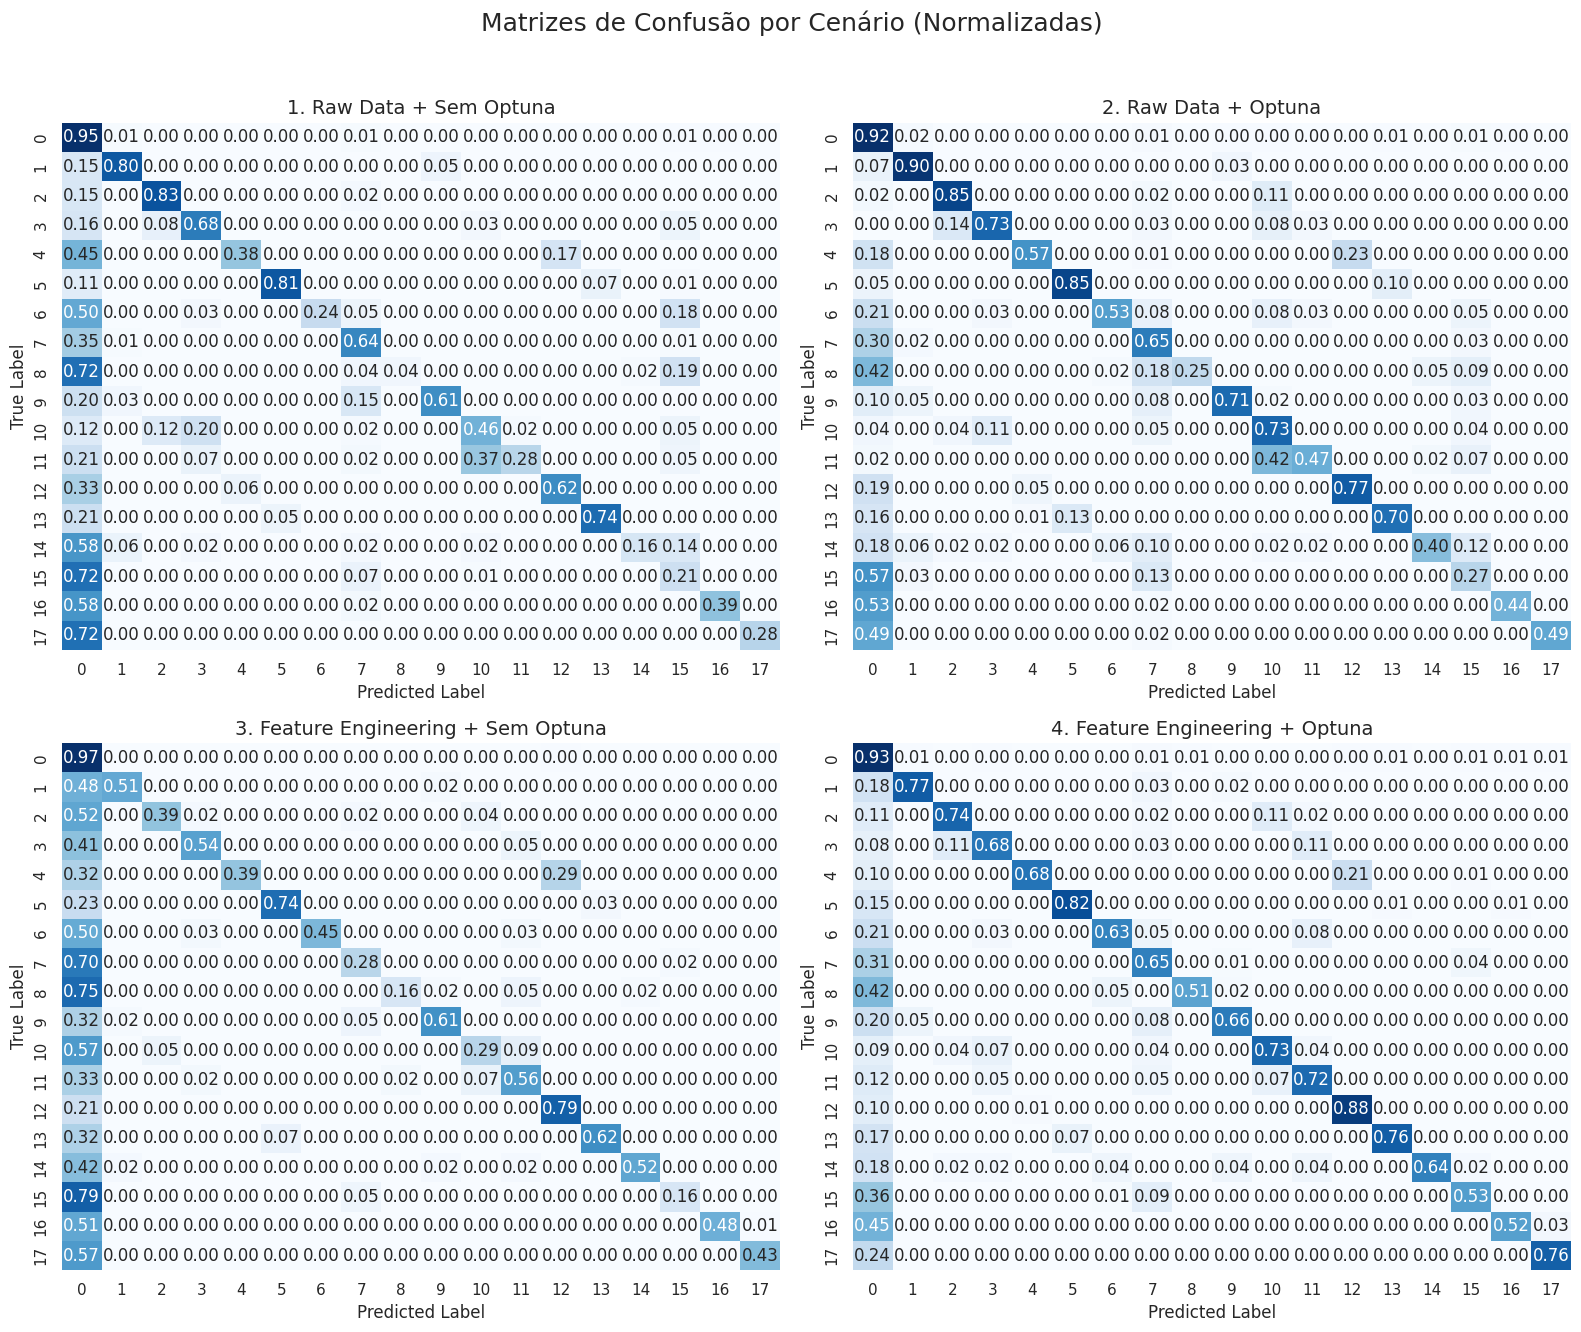

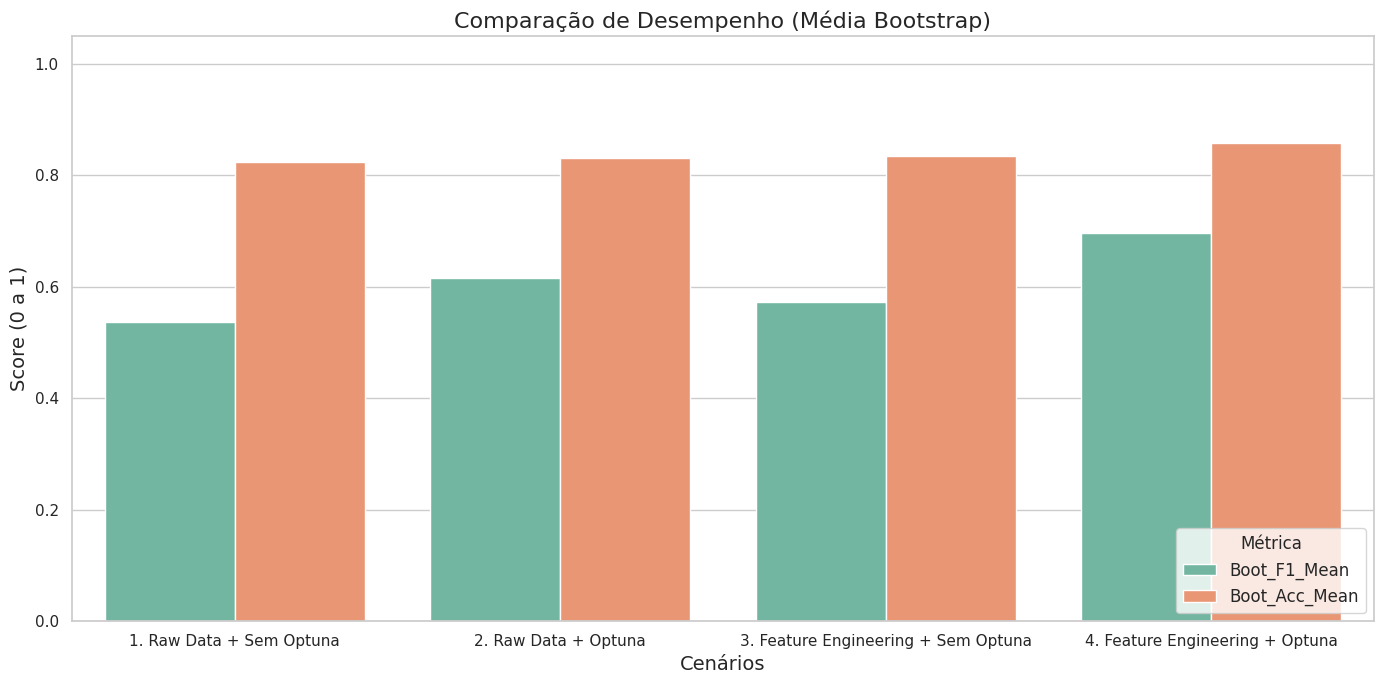

In [ ]:
from sklearn.metrics import confusion_matrix

df_final = pd.DataFrame(resultados)

print("\n=== TABELA DE RESULTADOS FINAIS (Médias Bootstrap) ===")
display(df_final[['Cenário', 'Boot_F1_Mean', 'Boot_Acc_Mean']])

# --- Plotar Matrizes de Confusão ---
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Matrizes de Confusão por Cenário (Normalizadas)', fontsize=18, y=0.95)

cenarios_nomes = list(predicoes.keys())
for i, ax in enumerate(axes.flat):
    if i < len(cenarios_nomes):
        nome = cenarios_nomes[i]
        y_pred_cenario = predicoes[nome]
        # Normalizando pelas classes verdadeiras (linhas)
        cm = confusion_matrix(y_test, y_pred_cenario, normalize='true')
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar=False)
        ax.set_title(nome, fontsize=14)
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# --- Plotar Histograma Comparativo (Barplot) ---
df_melted = df_final.melt(id_vars='Cenário',
                          value_vars=['Boot_F1_Mean', 'Boot_Acc_Mean'],
                          var_name='Métrica', value_name='Score')

plt.figure(figsize=(14, 7))
sns.barplot(data=df_melted, x='Cenário', y='Score', hue='Métrica', palette='Set2')
plt.title("Comparação de Desempenho (Média Bootstrap)", fontsize=16)
plt.ylabel("Score (0 a 1)", fontsize=14)
plt.xlabel("Cenários", fontsize=14)
plt.ylim(0, 1.05)
plt.xticks(fontsize=11)
plt.legend(title='Métrica', loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()